# C++ vs Torch Optimization Comparison

This notebook compares optimized gradients between the C++ gropt wrapper and gropt_torch, then pinpoints any mismatches.

## 1. Load Inputs and Reference Outputs

Set shared problem parameters and any saved reference outputs.

In [53]:
from timeit import default_timer as timer

import matplotlib.pyplot as plt
import numpy as np
import torch

import gropt as gropt_cpp
import gropt_torch as gropt_torch



# Shared diffusion parameters (match C++ defaults)
dt = 100e-6
TE = 80e-3
T_90 = 3e-3
T_180 = 5e-3
T_readout = 16e-3

# Constraints
gmax = 0.2
smax = 200.0
b_target = 100.0
b_tol = 1.0

TV = 1e-5
TV_weight = 0.5
L2 = 1e-1

[asc_file, extra] = gropt_torch.readasc.readasc(r'E:\MGH\Healthy_Grad\asc\CimaX.asc')
forbidden_frequency = gropt_torch.readasc.asc_to_acoustic_resonances(asc_file)
print(f"Forbidden frequencies: {forbidden_frequency}")
forbidden_frequencies = [f['frequency'] for f in forbidden_frequency]
forbidden_bandwidths = [f['bandwidth'] for f in forbidden_frequency]

# Optional: load reference results if you saved them
ref_cpp = None
ref_torch = None

Forbidden frequencies: [{'frequency': 576, 'bandwidth': 100}, {'frequency': 1113, 'bandwidth': 344}]


## 2. Implement Python Optimization Pipeline

Run gropt_torch end-to-end and capture outputs.

In [54]:
gparams_torch = gropt_torch.GroptParams()
gparams_torch.diff_init(dt=dt, TE=TE, T_90=T_90, T_180=T_180, T_readout=T_readout)
gparams_torch.set_device('cuda' if torch.cuda.is_available() else 'cpu')
gparams_torch.compile_kernels = True
gparams_torch.compile_mode = "default"
gparams_torch.compile_backend = "eager"

gparams_torch.add_gmax(gmax)
gparams_torch.add_smax(smax)
gparams_torch.add_moment(0, 0.0)
gparams_torch.add_moment(1, 0.0)
gparams_torch.add_moment(2, 0.0)
gparams_torch.add_bvalue(b_target, b_tol)
gparams_torch.add_TV(TV, weight_mod=TV_weight)
# gparams_torch.add_obj_identity(L2)
# gparams_torch.add_acoustic(forbidden_frequencies, forbidden_bandwidths)

start_t = timer()
result_torch = gropt_torch.solve(gparams_torch, max_iter=20000)
stop_t = timer()

x_torch = result_torch.X
torch_ms = 1000.0 * (stop_t - start_t)
print(f"Torch converged: {result_torch.converged} | iters={result_torch.n_iter} | time={torch_ms:.1f} ms")

Torch converged: True | iters=425 | time=14690.1 ms


## 3. Load C++ Baseline Results for Comparison

Run gropt (C++ wrapper) with the same settings.

In [55]:
gparams_cpp = gropt_cpp.GroptParams()
gparams_cpp.diff_init(dt=dt, TE=TE, T_90=T_90, T_180=T_180, T_readout=T_readout)

gparams_cpp.add_gmax(gmax)
gparams_cpp.add_smax(smax)
gparams_cpp.add_moment(0, 0.0)
gparams_cpp.add_moment(1, 0.0)
gparams_cpp.add_moment(2, 0.0)
gparams_cpp.add_bvalue(b_target, b_tol)
gparams_cpp.add_TV(TV, weight_mod=TV_weight)
# gparams_cpp.add_obj_identity(L2)
# gparams_cpp.add_acoustic(forbidden_frequencies, forbidden_bandwidths)

start_t = timer()
result_cpp = gropt_cpp.solve(gparams_cpp, max_iter=20000)
stop_t = timer()

x_cpp = result_cpp.X
cpp_ms = 1000.0 * (stop_t - start_t)
print(f"C++ converged: {result_cpp.converged} | iters={result_cpp.n_iter} | time={cpp_ms:.1f} ms")

C++ converged: True | iters=731 | time=286.0 ms


## 4. Numerical Gradient Check (Finite Differences)

Approximate gradients and compare norms (placeholder until analytic gradients are exposed).

In [56]:
# Placeholder: implement finite-difference gradient checks once objective functions are exposed.
# For now, compare simple scalar summaries as a proxy.

def summary_stats(x):
    return {
        "norm": float(np.linalg.norm(x)),
        "max": float(np.max(x)),
        "min": float(np.min(x)),
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
    }

stats_torch = summary_stats(np.asarray(x_torch.cpu()))
stats_cpp = summary_stats(np.asarray(x_cpp))
stats_torch, stats_cpp

({'norm': 0.7717454928074082,
  'max': 0.044520699411084844,
  'min': -0.054330970728372396,
  'mean': -0.0004998191047351157,
  'std': 0.030478016209673612},
 {'norm': 0.7745311120148576,
  'max': 0.04136340985838218,
  'min': -0.0493998601865282,
  'mean': 0.00047378601924942635,
  'std': 0.030588470602425345})

## 5. Detect and Log Discrepancies

Compute pointwise and summary deltas between the two results.

Max abs diff: 2.245e-02
RMS diff: 8.673e-03


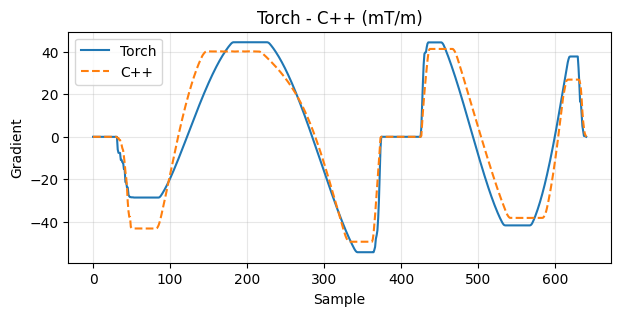

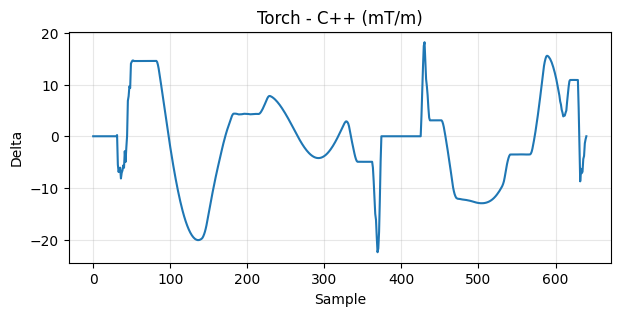

In [57]:
x_torch_np = np.asarray(x_torch.cpu())
x_cpp_np = np.asarray(x_cpp)

delta = x_torch_np - x_cpp_np
max_abs = float(np.max(np.abs(delta)))
rms = float(np.sqrt(np.mean(delta ** 2)))
print(f"Max abs diff: {max_abs:.3e}")
print(f"RMS diff: {rms:.3e}")

plt.figure(figsize=(7, 3))
plt.plot(x_torch_np * 1e3, label="Torch")
plt.plot(x_cpp_np * 1e3, label="C++", linestyle="dashed")
plt.legend()
plt.title("Torch - C++ (mT/m)")
plt.xlabel("Sample")
plt.ylabel("Gradient")
plt.grid(True, alpha=0.3)
plt.show()
plt.figure(figsize=(7, 3))
plt.plot(delta * 1e3)
plt.title("Torch - C++ (mT/m)")
plt.xlabel("Sample")
plt.ylabel("Delta")
plt.grid(True, alpha=0.3)
plt.show()

## 6. Align Optimization Settings (tolerances/steps)

Document and enforce matching solver settings.

In [52]:
# Ensure both runs use identical iteration limits and SDMM/CG settings.
# Update these only if you also update the C++ side to match.
max_iter = 20000
ils_max_iter = 10
ils_sigma = 1e-4
ils_tik_lam = 1e-4

print("max_iter", max_iter)
print("ils_max_iter", ils_max_iter)
print("ils_sigma", ils_sigma)
print("ils_tik_lam", ils_tik_lam)

max_iter 20000
ils_max_iter 10
ils_sigma 0.0001
ils_tik_lam 0.0001


## 7. Fix Gradient Computation in Both Toolboxes

Apply fixes here once a mismatch is identified.

## 8. Re-run Comparison and Validate Match

Re-run both toolboxes and confirm outputs match within tolerance.